In [227]:
load('.RData')

In [228]:
library(ropls)
library(ggplot2)
library(ggpubr)
library(RColorBrewer)
library(HotellingEllipse)
library(ggforce)

In [229]:
write.csv(df, 'datos.csv')

In [230]:
head(df)

,MouseID,Genotype,Treatment,Behavior,class,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,⋯,P3525_N,pCASP9_N,PSD95_N,SNCA_N,Ubiquitin_N,pGSK3B_Tyr216_N,SHH_N,pS6_N,SYP_N,CaNA_N
,<chr>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,309_1,c,m,CS,cCSm,0.5036439,0.7471932,0.4301753,2.816329,5.990152,⋯,0.2475378,1.603310,2.014875,0.1082343,1.0449792,0.8315565,0.1888517,0.1063052,0.4270992,1.675652
2,309_2,c,m,CS,cCSm,0.5146171,0.6890635,0.4117703,2.789514,5.685038,⋯,0.2576322,1.671738,2.004605,0.1097485,1.0098831,0.8492704,0.2004036,0.1065922,0.4415813,1.743610
3,309_3,c,m,CS,cCSm,0.5091831,0.7302468,0.4183088,2.687201,5.622059,⋯,0.2553430,1.663550,2.016831,0.1081962,0.9968476,0.8467087,0.1936845,0.1083031,0.4357769,1.926427
4,309_4,c,m,CS,cCSm,0.4421067,0.6170762,0.3586263,2.466947,4.979503,⋯,0.2511031,1.484624,1.957233,0.1198832,0.9902247,0.8332768,0.1921119,0.1031838,0.3916910,1.700563
5,309_5,c,m,CS,cCSm,0.4349402,0.6174298,0.3588022,2.365785,4.718679,⋯,0.2517730,1.534835,2.009109,0.1195244,0.9977750,0.8786678,0.2056042,0.1047838,0.4341538,1.839730
6,309_6,c,m,CS,cCSm,0.4475064,0.6281758,0.3673881,2.385939,4.807635,⋯,0.2444853,1.507777,2.003535,0.1206872,0.9201782,0.8436793,0.1904695,0.1064762,0.4398331,1.816389


PCA
1047 samples x 71 variables
standard scaling of predictors
      R2X(cum) pre ort
Total    0.791   8   0


,R2X,R2X(cum),Iter.
,<dbl>,<dbl>,<dbl>
p1,0.2790,0.279,29
p2,0.1640,0.442,32
p3,0.1110,0.554,32
p4,0.0771,0.631,33
p5,0.0489,0.680,101
p6,0.0469,0.727,41
p7,0.0342,0.761,90
p8,0.0299,0.791,47


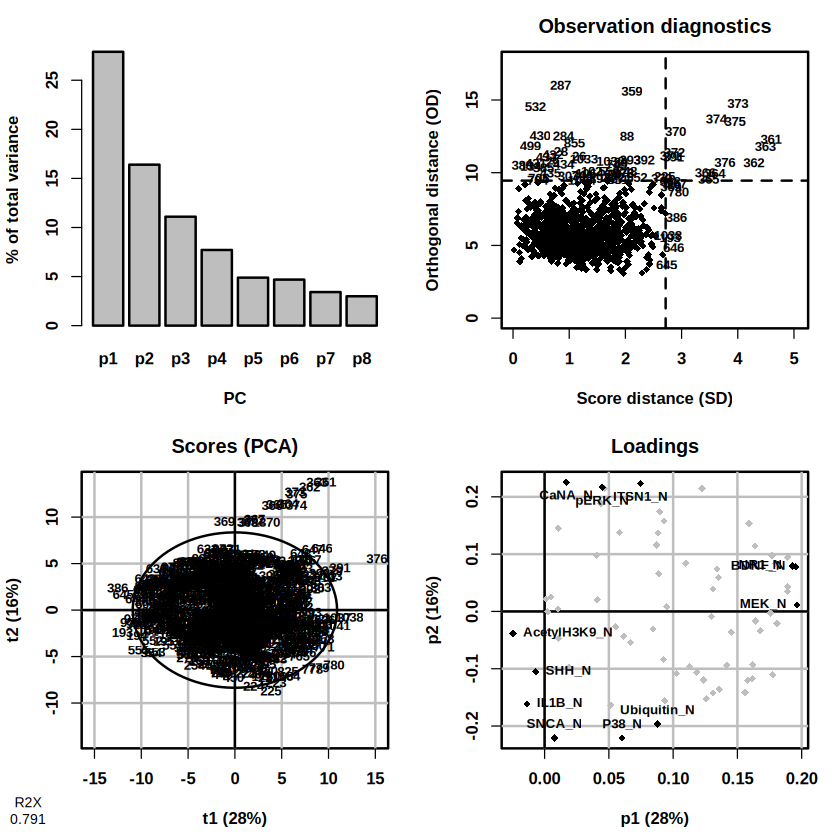

In [239]:
res.pca <- opls(df[, 6:76], algoC = 'nipals', scaleC = 'standard', predI = 8)
res.pca@modelDF

In [240]:
scores<- getScoreMN(res.pca)
loadings <- getLoadingMN(res.pca)

head(scores)

,p1,p2,p3,p4,p5,p6,p7,p8
1,4.3237549,4.853932,1.8245461,2.2444505,-1.421647,-1.0470291,-1.015441,-1.4804418
2,2.6903148,4.824470,0.8986034,1.6357920,-1.068910,-0.7584787,-1.135491,-1.2695950
3,2.8011759,5.060514,0.6376479,1.2900489,-1.107260,-0.5640815,-1.234666,-1.4669117
4,0.4563917,3.521160,2.6790677,0.7902433,-1.561983,-0.7783130,-1.526516,-0.8733920
5,-0.6287467,3.719145,1.4793039,0.3469291,-1.360418,-0.5604256,-1.756441,-0.4358392
6,-0.6367510,3.901027,1.6984370,0.3865102,-1.717505,-0.3521659,-1.527186,-0.9693240


In [241]:
res_2PCs <- ellipseParam(data = as.data.frame(scores),
                        k = 2, pcx = 1, pcy = 2)
a1 <- res_2PCs$Ellipse$a.99pct
b1 <- res_2PCs$Ellipse$b.99pct
a2 <- res_2PCs$Ellipse$a.95pct
b2 <- res_2PCs$Ellipse$b.95pct
a2
b2 ### (8.35 es el corte con PC2), raiz cuadrada = 2.89, parece coincider con Score Distance

[1] 10.91413

[1] 8.355892

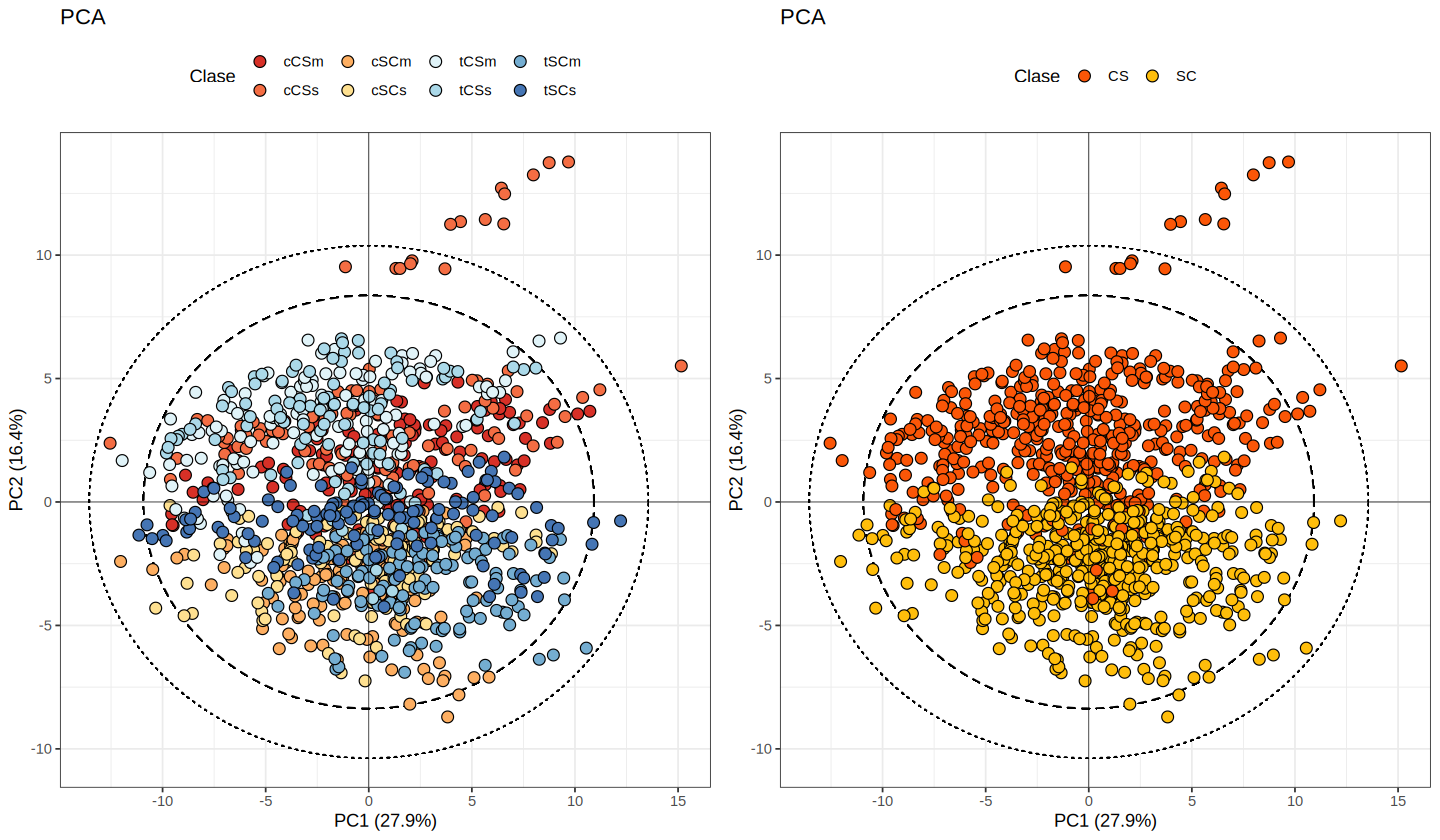

In [245]:
pp <- ggplot(as.data.frame(scores), aes(x = p1, y = p2)) +
        geom_ellipse(aes(x0 = 0, y0 = 0, a = a1, b = b1, angle = 0), size = .5, 
                     linetype = "dotted", fill = "white") +
        geom_ellipse(aes(x0 = 0, y0 = 0, a = a2, b = b2, angle = 0), size = .5, 
                     linetype = "dashed", fill = "white") +
        geom_point(aes(fill = df$class), color = 'black', shape = 21, size = 3) +
        scale_fill_manual(values = class_color) +
        geom_hline(yintercept = 0, linetype = "solid", color = "black", size = .2) +
        geom_vline(xintercept = 0, linetype = "solid", color = "black", size = .2) +
        theme_bw() + 
        theme(legend.position = 'top') +
        labs(title = 'PCA', fill = 'Clase') +
        xlab('PC1 (27.9%)') + 
        ylab('PC2 (16.4%)')

pb <- ggplot(as.data.frame(scores), aes(x = p1, y = p2)) +
        geom_ellipse(aes(x0 = 0, y0 = 0, a = a1, b = b1, angle = 0), size = .5, 
                     linetype = "dotted", fill = "white") +
        geom_ellipse(aes(x0 = 0, y0 = 0, a = a2, b = b2, angle = 0), size = .5, 
                     linetype = "dashed", fill = "white") +
        geom_point(aes(fill = df$Behavior), color = 'black', shape = 21, size = 3) +
        scale_fill_manual(values = Behavior_color) +
        geom_hline(yintercept = 0, linetype = "solid", color = "black", size = .2) +
        geom_vline(xintercept = 0, linetype = "solid", color = "black", size = .2) +
        theme_bw() + 
        theme(legend.position = 'top') +
        labs(title = 'PCA', fill = 'Clase') +
        xlab('PC1 (27.9%)') + 
        ylab('PC2 (16.4%)')
options(repr.plot.width = 12, repr.plot.height = 7)
ggarrange(pp, pb, ncol = 2, nrow = 1, align = 'h')
options(repr.plot.width = 7, repr.plot.height = 7)

#### Q Residuals

<img src='https://wikimedia.org/api/rest_v1/media/math/render/svg/b7d84fe5ac469637fb2b5d04f85202061ea026fd'></img>
Q Residuals are a lack-of-fit statistic calculated as the sum of squares of each row (sample) of E

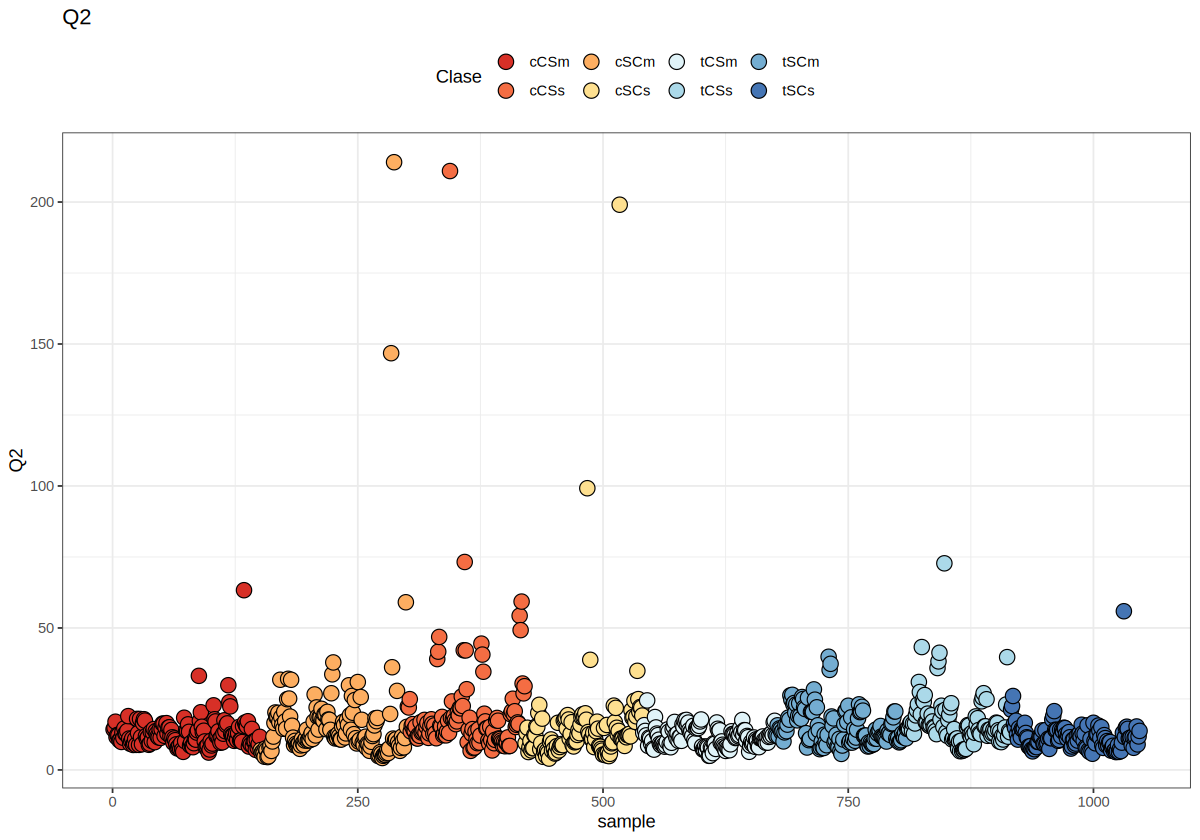

In [246]:
### E = X - TP^t
#head(res.pca@suppLs$xModelMN) MATRIZ ORIGINAL DE DATOS 'AUTOESCALADA'
X <- res.pca@suppLs$xModelMN

x1 <- X[1, ]
x2 <- X[2, ]
x3 <- X[3, ]
P <- loadings

## P*P^t
# t(x1) %*% ((diag(71) - loadings %*% t(loadings)) %*% x1)
# t(x2) %*% ((diag(71) - loadings %*% t(loadings)) %*% x2)
# t(x3) %*% ((diag(71) - loadings %*% t(loadings)) %*% x3)

Q2 <- diag(X %*% ((diag(71) - loadings %*% t(loadings)) %*% t(X))) ## Los valores en la diagonal

Q2 <- data.frame(sample = 1:nrow(X), Q2 = Q2)

options(repr.plot.width = 10, repr.plot.height = 7)
ggplot(Q2, aes(x = sample, y = Q2)) +
    geom_point(aes(fill = df$class), color = 'black', shape = 21, size = 4) +
    scale_fill_manual(values = class_color) +
    theme_bw() +
    theme(legend.position = 'top') +
    labs(title = 'Q2', fill = 'Clase')

#### Hotelling's T-Squared
<img src='https://wikimedia.org/api/rest_v1/media/math/render/svg/e9375c32cd6a1a2608e4e6ab982e8798e3dddf34'></img>


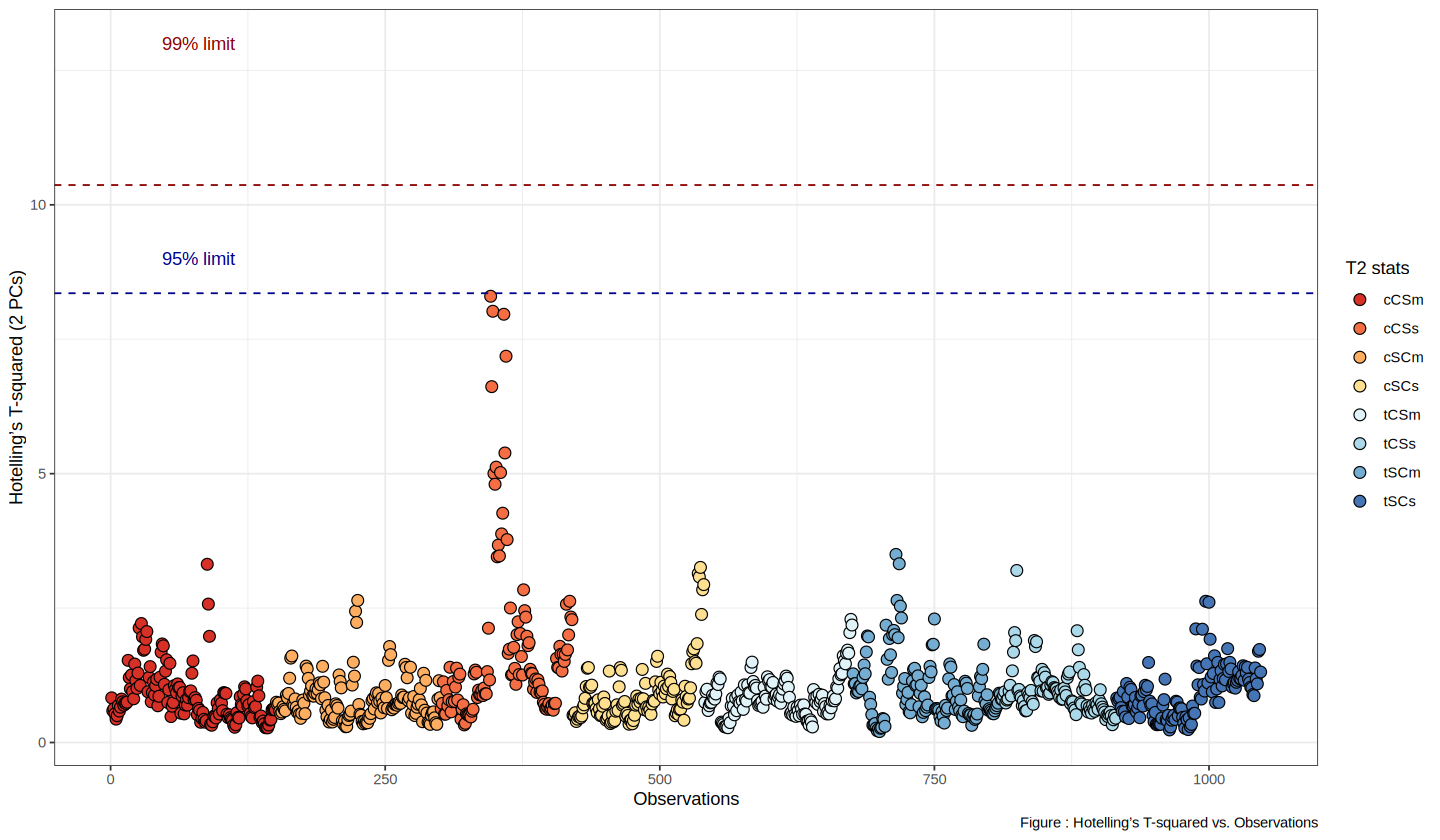

In [250]:
res_PCs <- ellipseParam(data = as.data.frame(scores), k = 8)
datos <- data.frame(T2 = res_PCs$Tsquare$value, 
                   obs = 1:nrow(as.data.frame(scores)))

options(repr.plot.width = 12, repr.plot.height = 7)
ggplot(datos) +
  geom_point(aes(x = obs, y = T2, fill = df$class), shape = 21, size = 3, color = "black") +
  #geom_segment(aes(x = obs, y = T2, xend = obs, yend = 0), size = .5) +
  scale_fill_manual(values = class_color) +
  geom_hline(yintercept = b1, linetype = "dashed", color = "darkred", size = .5) +
  geom_hline(yintercept = b2, linetype = "dashed", color = "darkblue", size = .5) +
  annotate("text", x = 80, y = 13, label = "99% limit", color = "darkred") +
  annotate("text", x = 80, y = 9, label = "95% limit", color = "darkblue") +
  labs(x = "Observations", 
       y = "Hotelling’s T-squared (2 PCs)", 
       fill = "T2 stats", 
       caption = "Figure : Hotelling’s T-squared vs. Observations") +
 theme_bw()
options(repr.plot.width = 7, repr.plot.height = 7)